In [1]:
import importlib
import cross_sectional_estimation_v1 as cse
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
from plot_style import apply
apply()
importlib.reload(cse)

<module 'cross_sectional_estimation_v1' from '/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/estimation/cross_sectional_estimation_v1.py'>

In [2]:
# Uncomment to re-run estimation (~30 min with n_jobs=-1)
out = cse.main(
    returns_csv="../data/X.csv",
    features_csv="../data/merged_return_topic_data.csv",
    out_dir="results_v1",
    subset_start=0,
    subset_end=-1,
    n_jobs=-1,
    save=True,
)

Estimating per stock:   0%|          | 0/1620 [00:00<?, ?it/s]

/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/estimation/stage2.py:24: RuntimeWarning: invalid value encountered in log
  return np.log(1 - kappa * np.exp(pred_t)) - np.log(1 - kappa * np.exp(pred_t1)) + intercept


Saved beta tensor  → results_v1/betas.h5  (1620, 180, 1859)  (2.17 GB uncompressed)
Saved summary      → results_v1/summary.csv


In [3]:
OUT_DIR = 'results_v1'

# ── Load tensor and coordinates ──────────────────────────────────────────────
with h5py.File(os.path.join(OUT_DIR, 'betas.h5'), 'r') as f:
    betas  = f['betas'][:]               # (n_stocks, n_topics, n_dates) float32
    stocks = f['stocks'][:].astype(str)
    topics = f['topics'][:].astype(str)
    dates  = pd.to_datetime(f['dates'][:].astype(str))

summary_df = pd.read_csv(os.path.join(OUT_DIR, 'summary.csv'), index_col=0)
summary_df.index = summary_df.index.astype(str)

# ── Derived quantities ───────────────────────────────────────────────────────
# NaN entries mean the stock had no data at that date; treat as not selected
betas_nz = np.nan_to_num(betas, nan=0.0)
sel      = betas_nz != 0                 # (n_stocks, n_topics, n_dates) bool

has_data     = np.isfinite(betas).any(axis=1)                      # (n_stocks, n_dates)
n_valid_days = has_data.sum(axis=1, keepdims=True).astype(float)   # (n_stocks, 1)

# Selection frequency per (stock, topic): fraction of valid days topic was selected
sel_mat = sel.sum(axis=2) / np.maximum(n_valid_days, 1)  # (n_stocks, n_topics)

# Active topics per (stock, date) — NaN where stock has no data
active_per_day = sel.sum(axis=1).astype(float)   # (n_stocks, n_dates)
active_per_day[~has_data] = np.nan

# Per-stock mean active topics over time
mean_num_active = np.nanmean(active_per_day, axis=1)  # (n_stocks,)
summary_df['mean_num_active'] = pd.Series(mean_num_active, index=stocks)

# Per-topic average selection frequency across all stocks
topic_avg_series = (
    pd.Series(sel_mat.mean(axis=0), index=topics)
    .sort_values(ascending=False)
)

# Filtered selection matrix: only non-failed stocks (at least one selection)
valid_mask = mean_num_active > 0
sel_mat_df = pd.DataFrame(sel_mat[valid_mask], index=stocks[valid_mask], columns=topics)
mean_sel   = sel_mat_df.mean()   # per-topic avg across non-failed stocks

print(f'Tensor  : {betas.shape}')
print(f'Stocks  : {len(stocks)}  ({valid_mask.sum()} non-failed)')
print(f'Topics  : {len(topics)}')
print(f'Dates   : {len(dates)}  ({dates[0].date()} \u2192 {dates[-1].date()})')
summary_df.head()

Tensor  : (1620, 180, 1859)
Stocks  : 1620  (527 non-failed)
Topics  : 180
Dates   : 1859  (2010-02-17 → 2017-06-30)


/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_5911/1028408300.py:29: RuntimeWarning: Mean of empty slice
  mean_num_active = np.nanmean(active_per_day, axis=1)  # (n_stocks,)


,window_size,n_lags,lambda,r2_insample_stage1,r2_oos_stage1,r2_insample_stage2,r2_oos_stage2,kappa,kappa_tstat,intercept,intercept_tstat,n_observations,n_windows,n_oos_predictions_stage2,return_variance,failed,mean_num_active
stock,,,,,,,,,,,,,,,,,
10065,30,1,4.489040e-07,0.965837,-0.627562,-1.032289e-09,-0.001437,1.769007e-08,7.719309e-07,0.000452,2.124555,1853,1856,NaN,0.000084,True,NaN
10145,30,1,4.489040e-07,0.976905,-0.630097,2.745344e-04,-0.001621,1.584786e-02,7.246422e-01,0.000731,2.350753,1853,1856,NaN,0.000181,NaN,63.167832
10294,30,1,4.489040e-07,0.970670,-0.631122,-1.262885e-08,-0.000353,1.180253e-07,5.144024e-06,0.000412,0.762835,1853,1856,NaN,0.000537,True,NaN
10375,30,1,4.489040e-07,0.971209,-0.672723,-1.167632e-09,-0.001398,4.443800e-08,1.972493e-06,0.000109,0.246594,1853,1856,NaN,0.000361,True,NaN
10516,30,1,4.489040e-07,0.965405,-0.592267,3.329936e-04,-0.008307,1.727662e-02,7.990265e-01,0.000265,0.731473,1853,1856,NaN,0.000242,NaN,67.571813


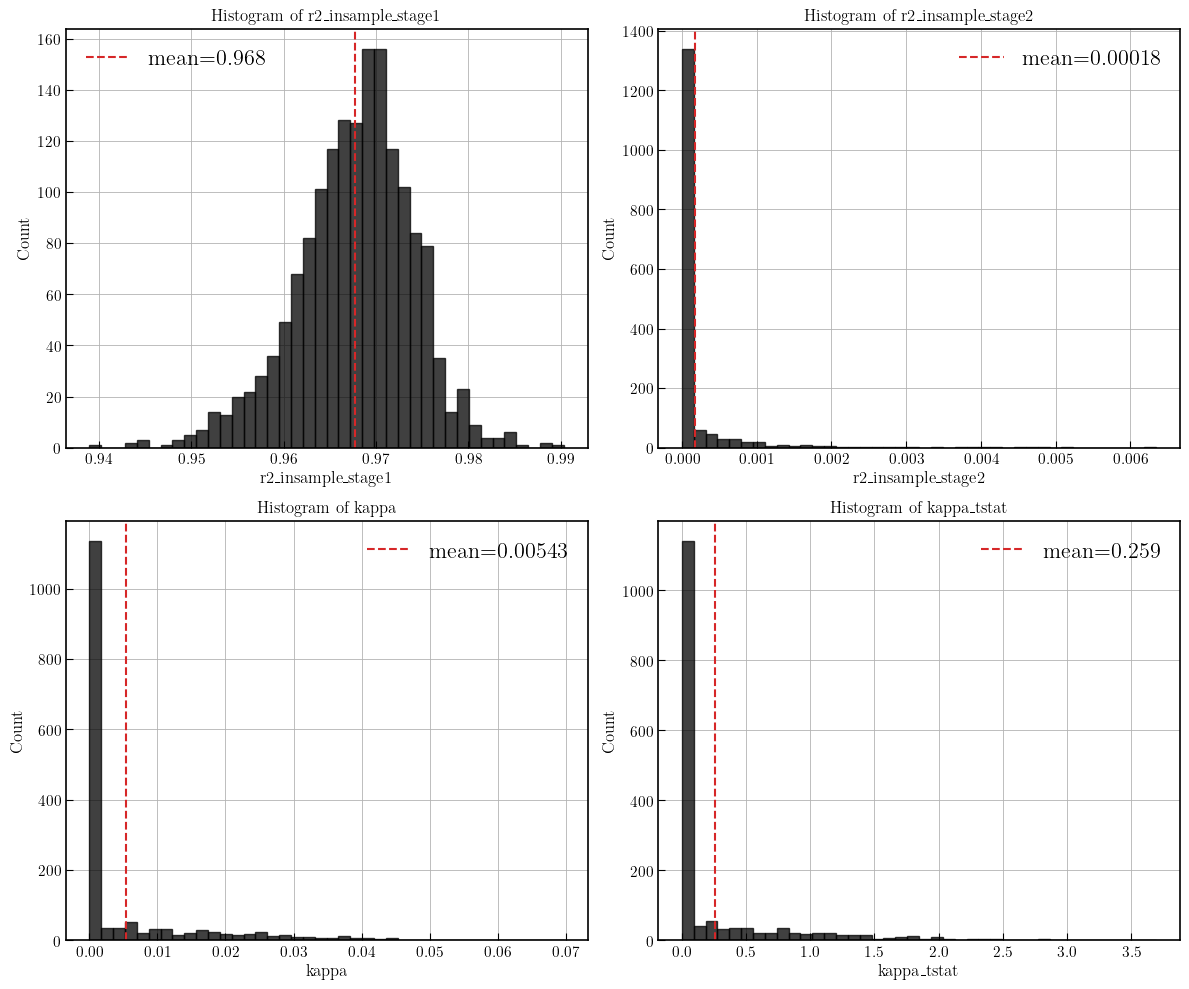

In [11]:
#plot of kappas, kappas t-stats, r2 stage 1 and stage 2, historgams
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = ["r2_insample_stage1", "r2_insample_stage2", "kappa", "kappa_tstat"]

for ax, col in zip(axes.flat, cols):
    s = summary_df[col].dropna()
    ax.hist(s, bins=40, edgecolor="black", alpha=0.75)
    ax.axvline(s.mean(), color="tab:red", linestyle="--", linewidth=1.5, label=f"mean={s.mean():.3g}")
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

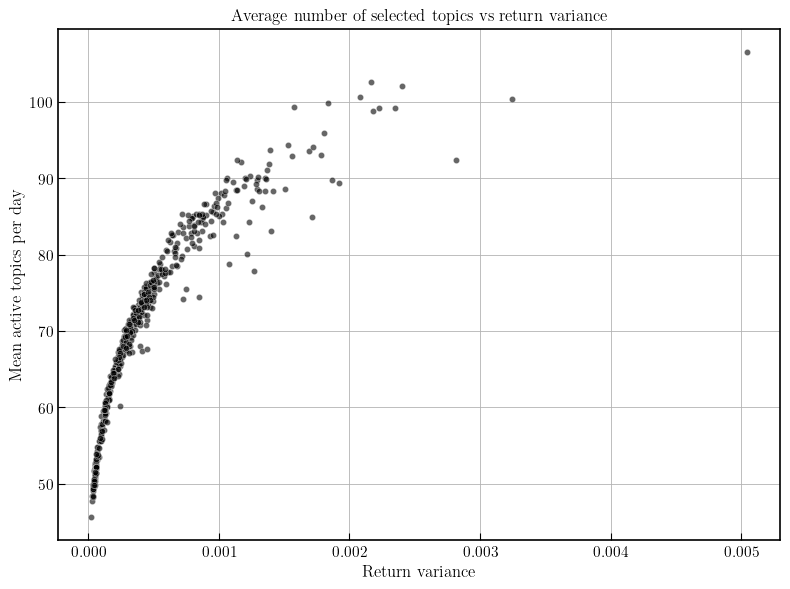

In [4]:
plot_df = summary_df[['return_variance', 'mean_num_active']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='return_variance', y='mean_num_active', ax=ax, alpha=0.6, s=20)
ax.set_title('Average number of selected topics vs return variance')
ax.set_xlabel('Return variance')
ax.set_ylabel('Mean active topics per day')
plt.tight_layout()
plt.show()

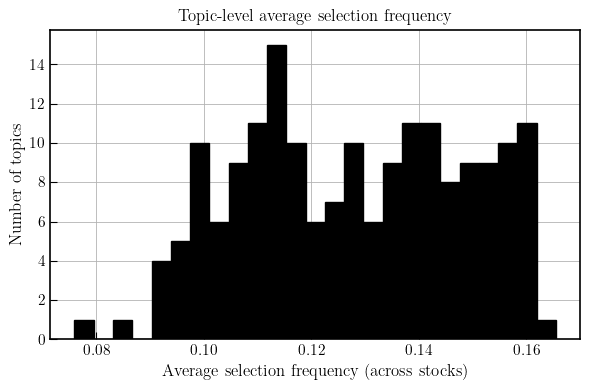

Top 10 most selected topics:


Internet             0.165529
Changes              0.161191
Research             0.161162
IPOs                 0.160996
Mobile_devices       0.160834
Scenario_analysis    0.160451
Police/crime         0.160263
Small_business       0.159727
Executive_pay        0.159461
Soft_drinks          0.158710
dtype: float64

In [5]:
topic_sel_nonzero = topic_avg_series[topic_avg_series > 0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(topic_sel_nonzero, bins=25, edgecolor='black')
ax.set_xlabel('Average selection frequency (across stocks)')
ax.set_ylabel('Number of topics')
ax.set_title('Topic-level average selection frequency')
plt.tight_layout()
plt.show()

print('Top 10 most selected topics:')
topic_avg_series.head(10)

## Topics selected by LASSO vs topics deemed important in academia

In [6]:
df_academia         = pd.read_csv('final_topics_from_papers.csv', index_col=0)
top_topics_academia = df_academia['topic'].value_counts()

topics_academia = set(t.replace(' ', '_') for t in top_topics_academia.index)
topics_lasso    = set(topic_avg_series.index)
common_topics   = topics_academia & topics_lasso

print(f'Common : {len(common_topics)}')
print(f'Academia: {len(topics_academia)}')
print(f'LASSO  : {len(topics_lasso)}')

common_df = pd.DataFrame({
    'avg_selection':  topic_avg_series.reindex(common_topics).fillna(0.0),
    'academia_count': top_topics_academia.reindex(common_topics).fillna(0.0),
})
common_df

Common : 75
Academia: 81
LASSO  : 180


,avg_selection,academia_count
Terrorism,0.102682,1.0
Product_prices,0.133224,0.0
Movie_industry,0.124686,0.0
Real_estate,0.113800,0.0
Mid-level_executives,0.113181,0.0
...,...,...
Control_stakes,0.141236,0.0
Long/short_term,0.093758,0.0
Competition,0.150734,3.0
Marketing,0.135399,4.0


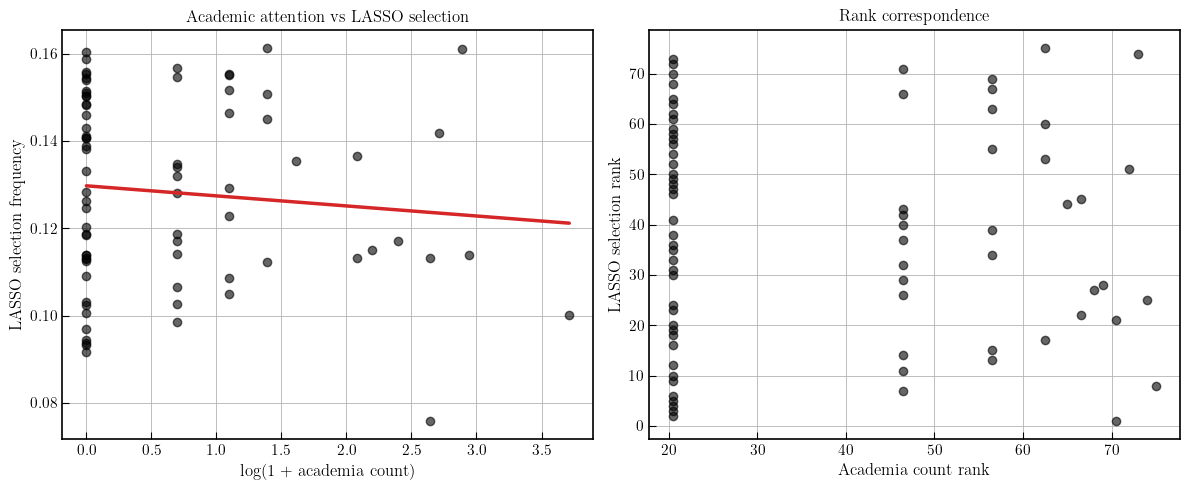

Spearman: -0.017
Pearson : -0.160


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: log academia count vs LASSO selection rate
x    = np.log1p(common_df['academia_count'])
y    = common_df['avg_selection']
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

axes[0].scatter(x, y, alpha=0.6)
axes[0].plot(x_line, coef[0] * x_line + coef[1], color='tab:red')
axes[0].set_xlabel('log(1 + academia count)')
axes[0].set_ylabel('LASSO selection frequency')
axes[0].set_title('Academic attention vs LASSO selection')

# Right: rank correspondence
axes[1].scatter(common_df['academia_count'].rank(), common_df['avg_selection'].rank(), alpha=0.6)
axes[1].set_xlabel('Academia count rank')
axes[1].set_ylabel('LASSO selection rank')
axes[1].set_title('Rank correspondence')

plt.tight_layout()
plt.show()

sp = common_df.corr(method='spearman').loc['avg_selection', 'academia_count']
pe = common_df.corr(method='pearson').loc['avg_selection', 'academia_count']
print(f'Spearman: {sp:.3f}')
print(f'Pearson : {pe:.3f}')

## Selected topics over time

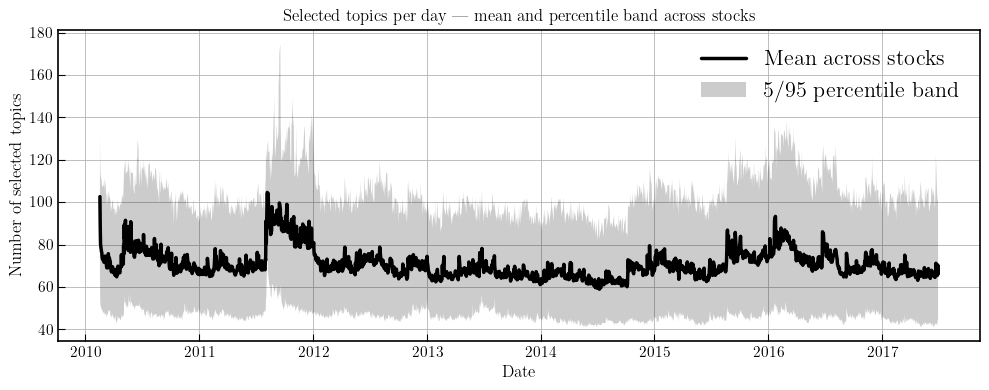

In [8]:
mean_over_time = np.nanmean(active_per_day, axis=0)
lo_over_time   = np.nanpercentile(active_per_day,  5, axis=0)
hi_over_time   = np.nanpercentile(active_per_day, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, mean_over_time, label='Mean across stocks')
ax.fill_between(dates, lo_over_time, hi_over_time, alpha=0.2, label='5/95 percentile band')
ax.set_xlabel('Date')
ax.set_ylabel('Number of selected topics')
ax.set_title('Selected topics per day \u2014 mean and percentile band across stocks')
ax.legend()
plt.tight_layout()
plt.show()

## Topic selection heterogeneity analysis

In [9]:
COL_OBS  = '#2166AC'
COL_NULL = '#D6604D'

N, T = sel_mat_df.shape

def gini_coef(arr):
    arr = arr[arr >= 0]
    if len(arr) == 0 or arr.sum() == 0:
        return np.nan
    arr = np.sort(arr)
    n, idx = len(arr), np.arange(1, len(arr) + 1)
    return float((2 * (idx * arr).sum() - (n + 1) * arr.sum()) / (n * arr.sum()))

def row_entropy(row):
    p = row.values[row.values > 0]
    if len(p) == 0:
        return np.nan
    p = p / p.sum()
    return float(scipy_entropy(p))

# ── Per-stock diversity metrics ───────────────────────────────────────────────
entropies  = sel_mat_df.apply(row_entropy, axis=1)
row_sums   = sel_mat_df.sum(axis=1).replace(0, np.nan)
normalized = sel_mat_df.div(row_sums, axis=0)

stock_div = pd.DataFrame({
    'entropy':         entropies,
    'eff_n_topics':    np.exp(entropies),
    'hhi':             (normalized ** 2).sum(axis=1),
    'n_active_topics': (sel_mat_df > 0).sum(axis=1),
})

# ── Per-topic heterogeneity ───────────────────────────────────────────────────
std_sel   = sel_mat_df.std()
topic_het = pd.DataFrame({
    'mean_sel':        mean_sel,
    'std_sel':         std_sel,
    'cv':              std_sel / mean_sel.replace(0, np.nan),
    'n_stocks_active': (sel_mat_df > 0).sum(),
    'gini':            sel_mat_df.apply(lambda c: gini_coef(c.values)),
}).sort_values('gini', ascending=False)

# ── Pairwise cosine similarity ────────────────────────────────────────────────
sim_matrix   = cosine_similarity(sel_mat_df.values)
upper_idx    = np.triu_indices(N, k=1)
pairwise_sim = sim_matrix[upper_idx]

# ── Analytical null (uniform selection across k active topics) ────────────────
k_active     = stock_div['n_active_topics'].replace(0, np.nan)
null_entropy = np.log(k_active)
null_eff_n   = k_active
null_hhi     = 1.0 / k_active

# ── Simulation null (B permutations of topic labels within each stock) ────────
B, MAX_PAIRS = 100, 50_000
rng          = np.random.default_rng(42)
mat_np       = sel_mat_df.values.copy()

null_ps_list = []
null_g_arr   = np.zeros((B, T))
null_cv_arr  = np.full((B, T), np.nan)

print(f'Running {B} permutations...', end=' ', flush=True)
for b in range(B):
    nm    = rng.permuted(mat_np, axis=1)
    sim_b = cosine_similarity(nm)
    ai, aj = np.triu_indices(N, k=1)
    if len(ai) > MAX_PAIRS:
        idx = rng.choice(len(ai), MAX_PAIRS, replace=False)
        ai, aj = ai[idx], aj[idx]
    null_ps_list.append(sim_b[ai, aj])
    null_g_arr[b] = [gini_coef(nm[:, t]) for t in range(T)]
    m = nm.mean(axis=0)
    s = nm.std(axis=0)
    null_cv_arr[b] = np.where(m > 0, s / m, np.nan)
print('done.')

null_ps_null = np.concatenate(null_ps_list)
null_g_s     = pd.Series(np.nanmean(null_g_arr,          axis=0), index=topics)
null_cv_s    = pd.Series(np.nanmean(null_cv_arr,          axis=0), index=topics)
null_g_lo    = pd.Series(np.nanpercentile(null_g_arr,   2.5, axis=0), index=topics)
null_g_hi    = pd.Series(np.nanpercentile(null_g_arr,  97.5, axis=0), index=topics)
null_cv_lo   = pd.Series(np.nanpercentile(null_cv_arr,  2.5, axis=0), index=topics)
null_cv_hi   = pd.Series(np.nanpercentile(null_cv_arr, 97.5, axis=0), index=topics)

print(f'Topic-selection matrix: {N} stocks \u00d7 {T} topics')

Running 100 permutations... done.
Topic-selection matrix: 527 stocks × 180 topics


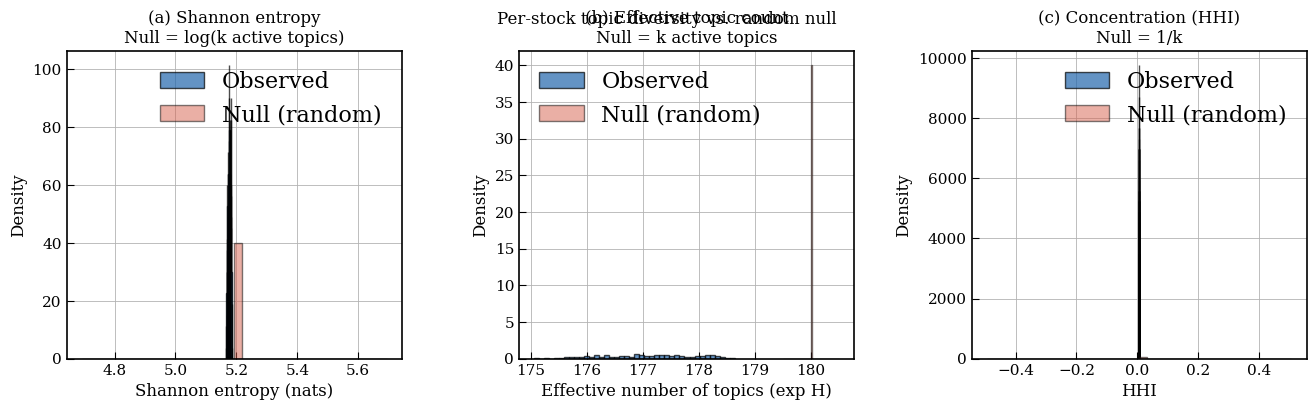

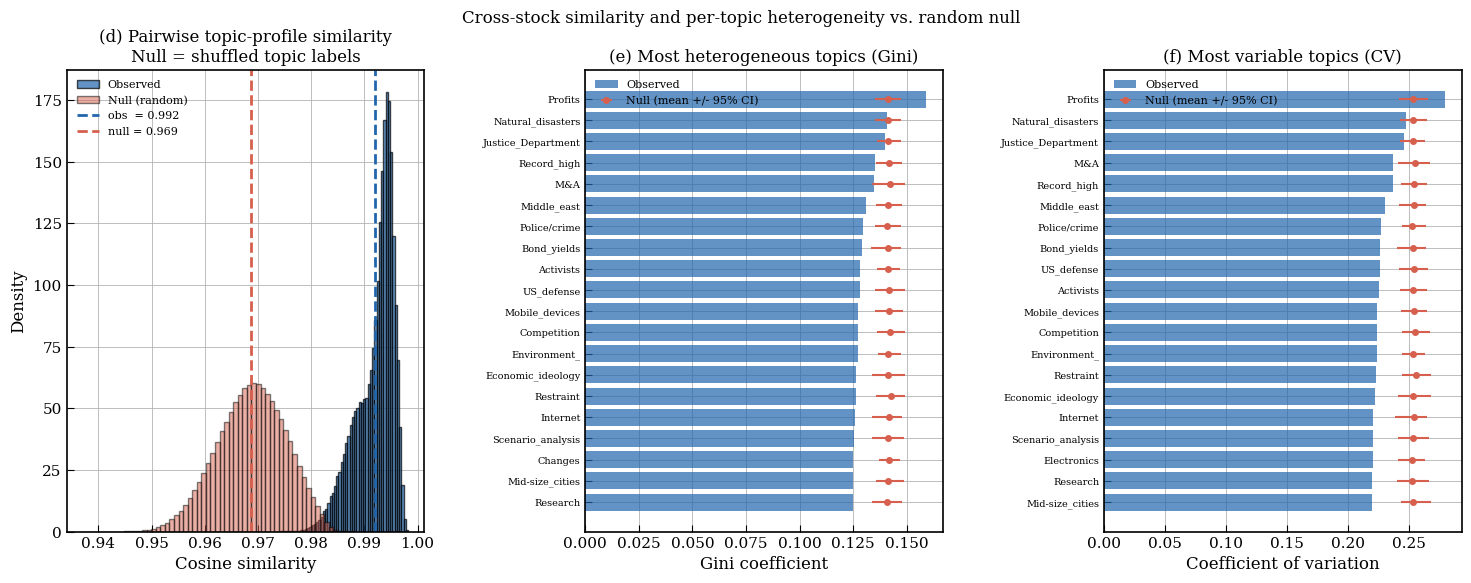


Observed vs. null -- aggregate summary:
  Metric               Observed         Null
  entropy (mean)         5.1765       5.1930
  eff_n (mean)         177.0661     180.0000
  HHI (mean)             0.0057       0.0056
  cos_sim (mean)         0.9920       0.9688
  Gini (mean)            0.1036       0.1415
  CV (mean)              0.1830       0.2534


In [10]:
obs_kw  = dict(bins=40, alpha=0.7, color=COL_OBS,  density=True, edgecolor='k', label='Observed')
null_kw = dict(bins=40, alpha=0.5, color=COL_NULL, density=True, edgecolor='k', label='Null (random)')

# usetex=True (set by plot_style) chokes on Unicode dashes/plusminus; disable for these figures
with plt.rc_context({'text.usetex': False}):

    # ── Figure 1: per-stock diversity ─────────────────────────────────────────
    fig1, ax1 = plt.subplots(1, 3, figsize=(16, 4))
    fig1.suptitle('Per-stock topic diversity vs. random null', fontsize=12)

    ax1[0].hist(stock_div['entropy'].dropna(), **obs_kw)
    ax1[0].hist(null_entropy.dropna(), **null_kw)
    ax1[0].set_xlabel('Shannon entropy (nats)')
    ax1[0].set_ylabel('Density')
    ax1[0].set_title('(a) Shannon entropy\nNull = log(k active topics)')
    ax1[0].legend()

    ax1[1].hist(stock_div['eff_n_topics'].dropna(), **obs_kw)
    ax1[1].hist(null_eff_n.dropna(), **null_kw)
    ax1[1].set_xlabel('Effective number of topics (exp H)')
    ax1[1].set_ylabel('Density')
    ax1[1].set_title('(b) Effective topic count\nNull = k active topics')
    ax1[1].legend()

    ax1[2].hist(stock_div['hhi'].dropna(), **obs_kw)
    ax1[2].hist(null_hhi.dropna(), **null_kw)
    ax1[2].set_xlabel('HHI')
    ax1[2].set_ylabel('Density')
    ax1[2].set_title('(c) Concentration (HHI)\nNull = 1/k')
    ax1[2].legend()

    fig1.subplots_adjust(wspace=0.35)
    plt.show()

    # ── Figure 2: cosine similarity + Gini / CV ───────────────────────────────
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 6))
    fig2.suptitle('Cross-stock similarity and per-topic heterogeneity vs. random null', fontsize=12)

    ax2[0].hist(pairwise_sim, bins=60, alpha=0.7, color=COL_OBS,  density=True, edgecolor='k', label='Observed')
    ax2[0].hist(null_ps_null, bins=60, alpha=0.5, color=COL_NULL, density=True, edgecolor='k', label='Null (random)')
    ax2[0].axvline(np.mean(pairwise_sim), color=COL_OBS,  lw=2, ls='--', label=f'obs  = {np.mean(pairwise_sim):.3f}')
    ax2[0].axvline(np.mean(null_ps_null), color=COL_NULL, lw=2, ls='--', label=f'null = {np.mean(null_ps_null):.3f}')
    ax2[0].set_xlabel('Cosine similarity')
    ax2[0].set_ylabel('Density')
    ax2[0].set_title('(d) Pairwise topic-profile similarity\nNull = shuffled topic labels')
    ax2[0].legend(fontsize=8)

    top20_gini = topic_het.nlargest(20, 'gini')
    yp = np.arange(len(top20_gini))
    ax2[1].barh(yp, top20_gini['gini'].values[::-1], color=COL_OBS, alpha=0.7, label='Observed')
    ax2[1].errorbar(
        null_g_s.reindex(top20_gini.index).values[::-1], yp,
        xerr=[
            (null_g_s - null_g_lo).reindex(top20_gini.index).values[::-1],
            (null_g_hi - null_g_s).reindex(top20_gini.index).values[::-1],
        ],
        fmt='o', color=COL_NULL, ms=4, lw=1.5, label='Null (mean +/- 95% CI)'
    )
    ax2[1].set_yticks(yp)
    ax2[1].set_yticklabels(top20_gini.index[::-1], fontsize=7)
    ax2[1].set_xlabel('Gini coefficient')
    ax2[1].set_title('(e) Most heterogeneous topics (Gini)')
    ax2[1].legend(fontsize=8)

    top20_cv = topic_het.nlargest(20, 'cv')
    yp = np.arange(len(top20_cv))
    ax2[2].barh(yp, top20_cv['cv'].values[::-1], color=COL_OBS, alpha=0.7, label='Observed')
    ax2[2].errorbar(
        null_cv_s.reindex(top20_cv.index).values[::-1], yp,
        xerr=[
            (null_cv_s - null_cv_lo).reindex(top20_cv.index).values[::-1],
            (null_cv_hi - null_cv_s).reindex(top20_cv.index).values[::-1],
        ],
        fmt='o', color=COL_NULL, ms=4, lw=1.5, label='Null (mean +/- 95% CI)'
    )
    ax2[2].set_yticks(yp)
    ax2[2].set_yticklabels(top20_cv.index[::-1], fontsize=7)
    ax2[2].set_xlabel('Coefficient of variation')
    ax2[2].set_title('(f) Most variable topics (CV)')
    ax2[2].legend(fontsize=8)

    fig2.subplots_adjust(wspace=0.45)
    plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nObserved vs. null -- aggregate summary:')
rows = [
    ('entropy (mean)',  stock_div['entropy'].mean(),      null_entropy.mean()),
    ('eff_n (mean)',    stock_div['eff_n_topics'].mean(), null_eff_n.mean()),
    ('HHI (mean)',      stock_div['hhi'].mean(),          null_hhi.mean()),
    ('cos_sim (mean)',  np.mean(pairwise_sim),            np.mean(null_ps_null)),
    ('Gini (mean)',     topic_het['gini'].mean(),         np.nanmean(null_g_arr)),
    ('CV (mean)',       topic_het['cv'].mean(),           np.nanmean(null_cv_arr)),
]
print(f'  {"Metric":<18} {"Observed":>10}   {"Null":>10}')
for name, obs, null in rows:
    print(f'  {name:<18} {obs:>10.4f}   {null:>10.4f}')

## Stock \u00d7 topic selection frequency heatmap

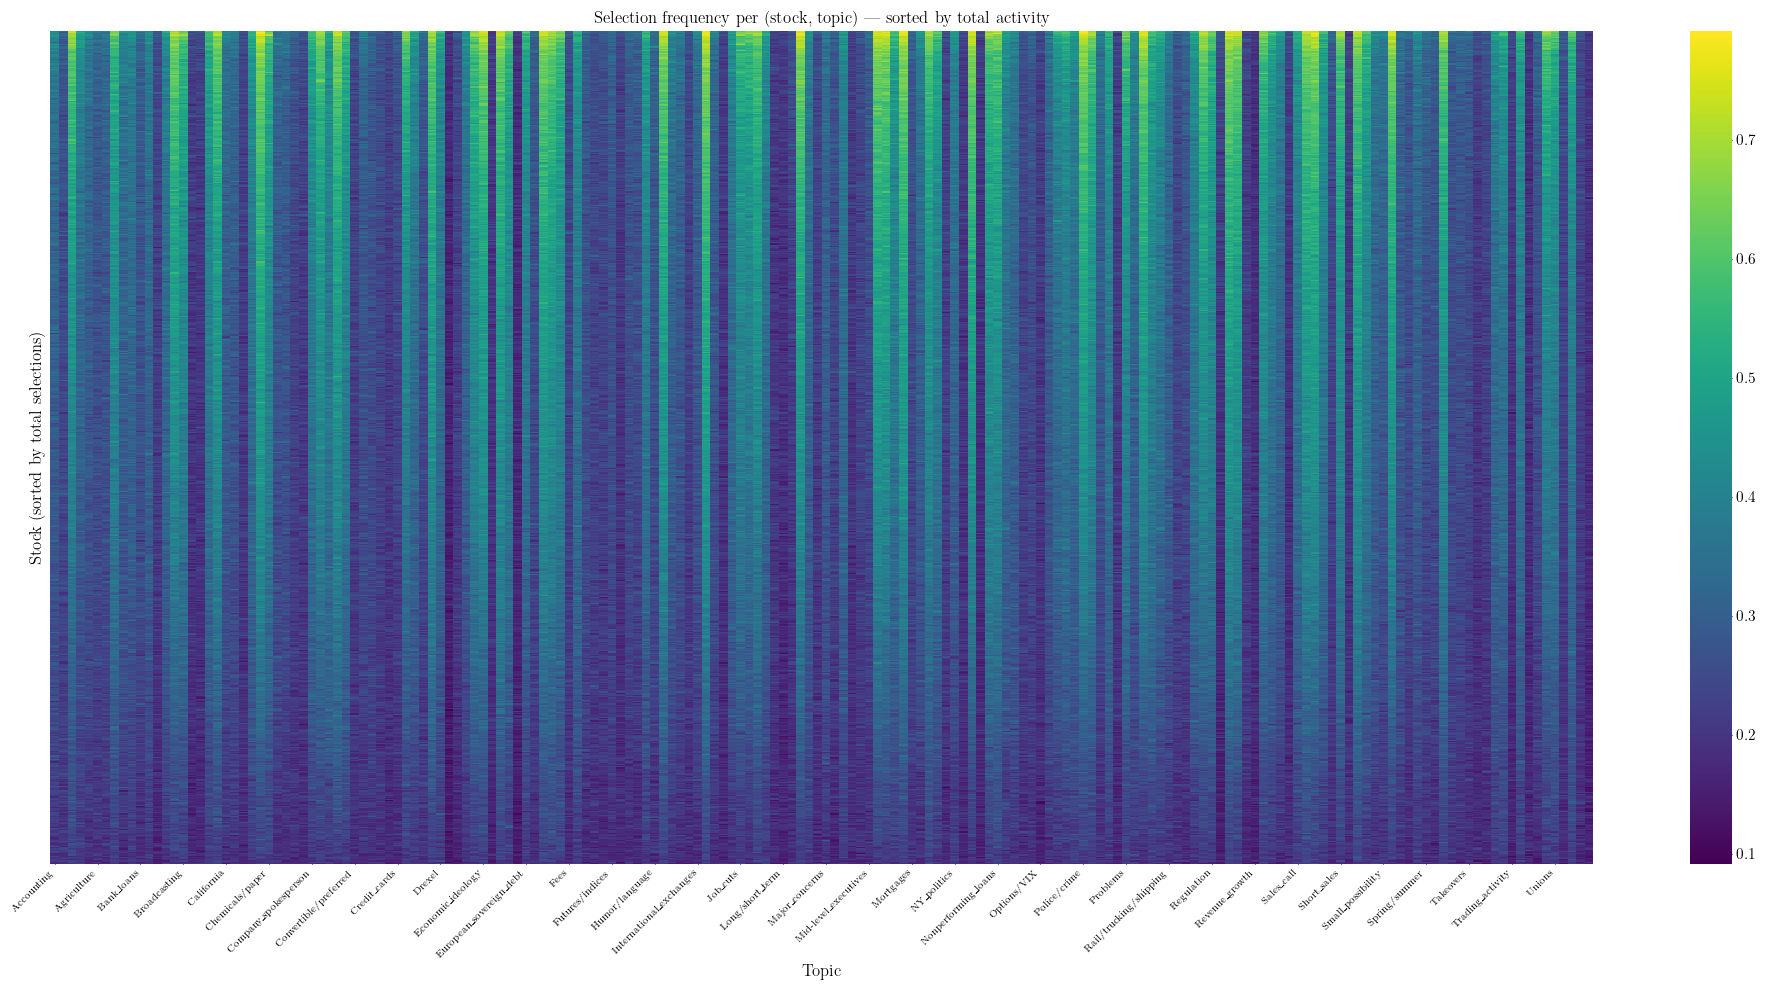

In [15]:
# Sort stocks by total selection activity (most active on top)
sort_order = sel_mat_df.sum(axis=1).sort_values(ascending=False).index
heatmap_df = sel_mat_df.loc[sort_order]

fig, ax = plt.subplots(figsize=(20, 10))
# xticklabels=5 shows every 5th topic label — avoids the seaborn layout crash
# that occurs when rendering all 180 labels at once
sns.heatmap(heatmap_df, cmap='viridis', ax=ax, xticklabels=5, yticklabels=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_title('Selection frequency per (stock, topic) — sorted by total activity')
ax.set_xlabel('Topic')
ax.set_ylabel('Stock (sorted by total selections)')
plt.tight_layout()
plt.show()